In [1]:
import pandas as pd
import numpy as np


df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/weather_classification_data.csv")

print("Columns:", df.columns.tolist())
print(df.head())


Columns: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location', 'Weather Type']
   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  partly cloudy   
1         39.0        96         8.5               71.0  partly cloudy   
2         30.0        64         7.0               16.0          clear   
3         38.0        83         1.5               82.0          clear   
4         27.0        74        17.0               66.0       overcast   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2  Winter              3.5    inland   
1               1011.43         7  Spring             10.0    inland   
2               1018.72         5  Spring              5.5  mountain   
3               1026.25         7  Spring              1.0   coastal   
4              

In [2]:
df.isnull().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Temperature           13200 non-null  bool 
 1   Humidity              13200 non-null  bool 
 2   Wind Speed            13200 non-null  bool 
 3   Precipitation (%)     13200 non-null  bool 
 4   Cloud Cover           13200 non-null  bool 
 5   Atmospheric Pressure  13200 non-null  bool 
 6   UV Index              13200 non-null  bool 
 7   Season                13200 non-null  bool 
 8   Visibility (km)       13200 non-null  bool 
 9   Location              13200 non-null  bool 
 10  Weather Type          13200 non-null  bool 
dtypes: bool(11)
memory usage: 141.9 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,13200.0,19.127576,17.386327,-25.00,4.0,21.00,31.0000,109.00
Humidity,13200.0,68.710833,20.194248,20.00,57.0,70.00,84.0000,109.00
Wind Speed,13200.0,9.832197,6.908704,0.00,5.0,9.00,13.5000,48.50
Precipitation (%),13200.0,53.644394,31.946541,0.00,19.0,58.00,82.0000,109.00
Atmospheric Pressure,13200.0,1005.827896,37.199589,800.12,994.8,1007.65,1016.7725,1199.21
UV Index,13200.0,4.005758,3.856600,0.00,1.0,3.00,7.0000,14.00
Visibility (km),13200.0,5.462917,3.371499,0.00,3.0,5.00,7.5000,20.00


/tmp/ipython-input-2004401399.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


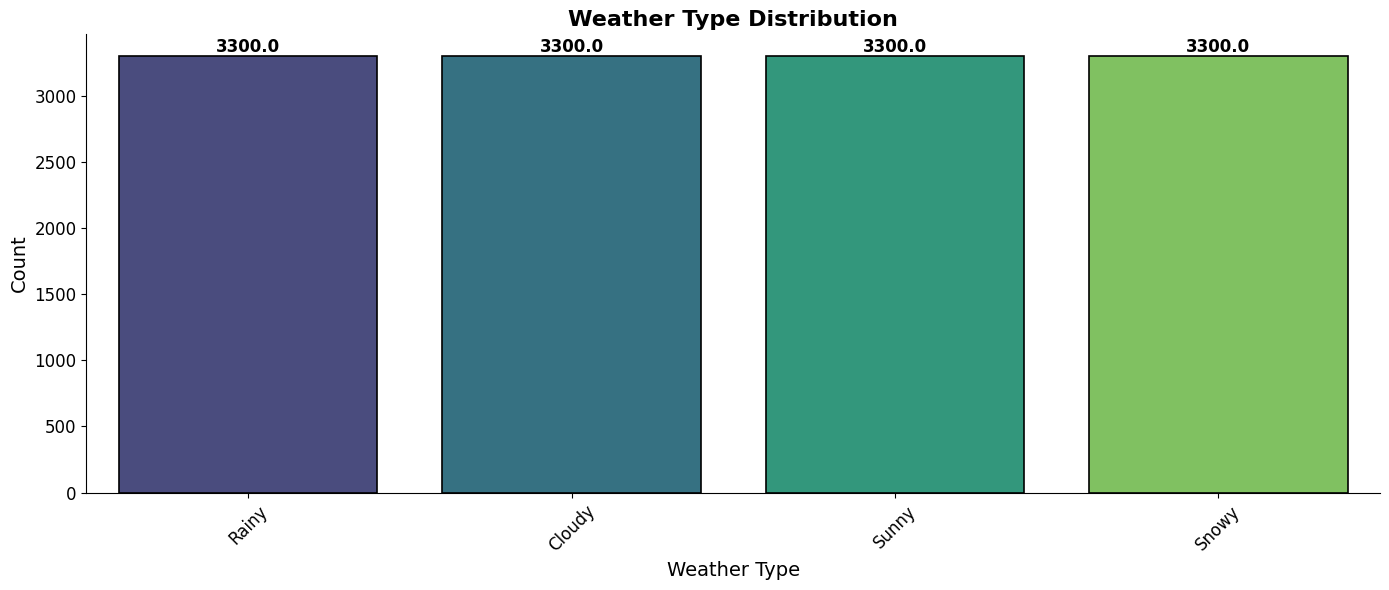

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))


palette = sns.color_palette("viridis", n_colors=df["Weather Type"].nunique())

ax = sns.countplot(
    data=df,
    x="Weather Type",
    palette=palette,
    edgecolor="black",
    linewidth=1.2
)


for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )


plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.title("Weather Type Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Weather Type", fontsize=14)
plt.ylabel("Count", fontsize=14)
sns.despine()

plt.tight_layout()
plt.show()


# **Detecting Outliers (Bad Data)**

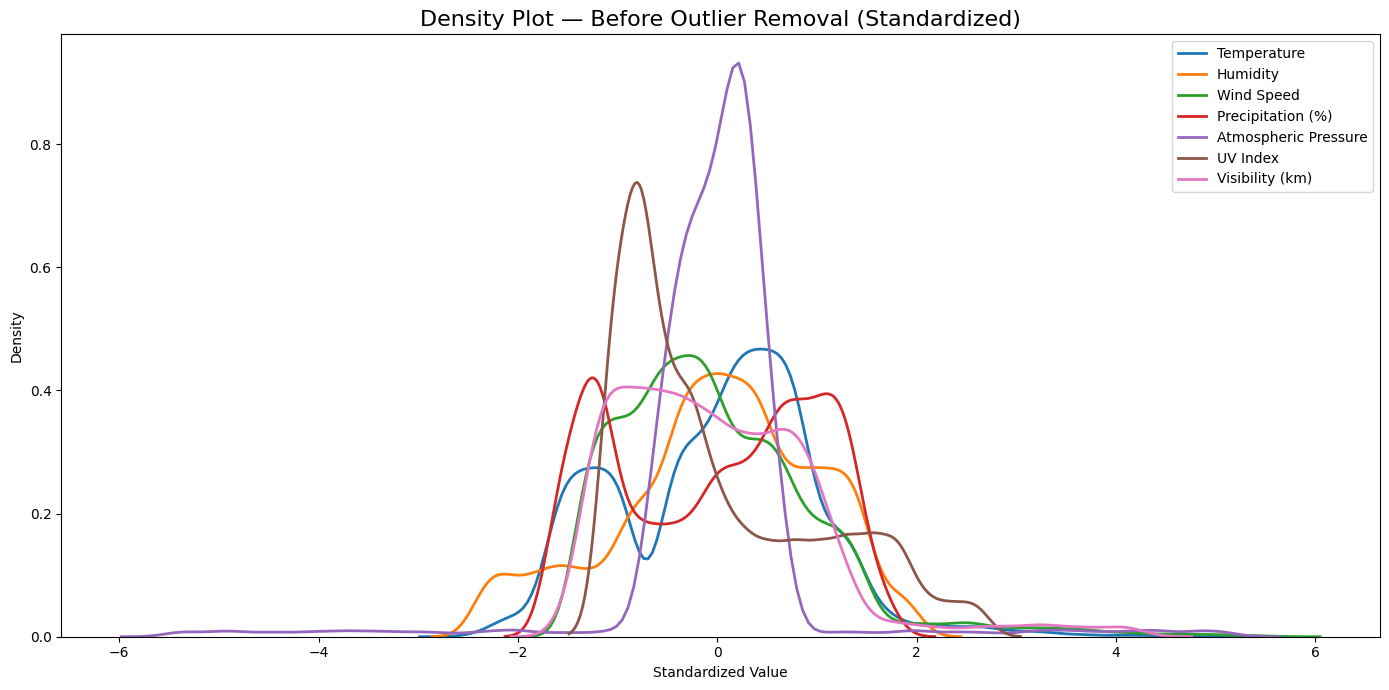

In [5]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_df = df.select_dtypes(include='number')

# Standardize so all columns have mean=0 and std=1
scaled = StandardScaler().fit_transform(numeric_df)
scaled_df = pd.DataFrame(scaled, columns=numeric_df.columns)

plt.figure(figsize=(14,7))

# Plot all KDEs after scaling
for col in scaled_df.columns:
    sns.kdeplot(scaled_df[col], fill=False, linewidth=2, label=col)

plt.title("Density Plot — Before Outlier Removal (Standardized)", fontsize=16)
plt.xlabel("Standardized Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


**Boxplots (visual)**

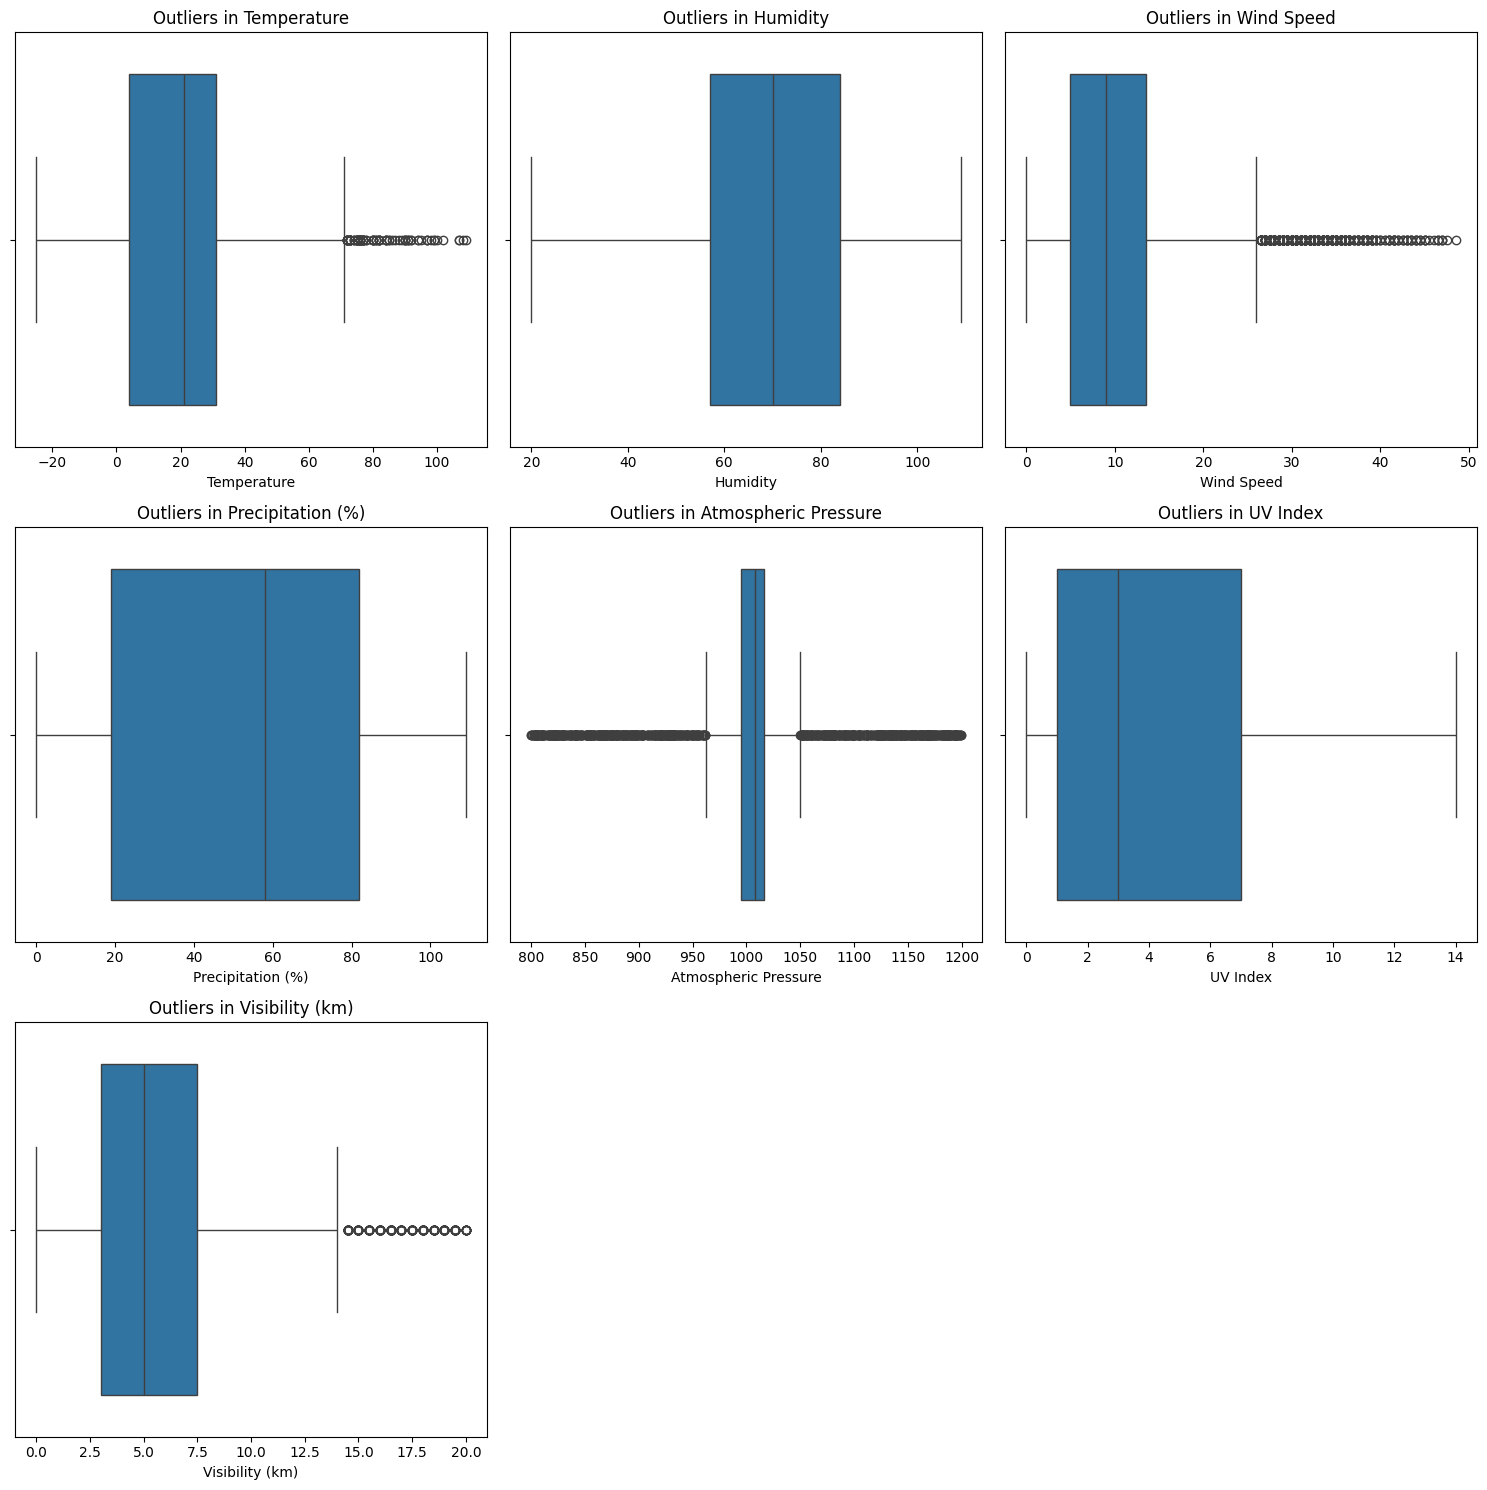

In [6]:
import math

num_cols = df.select_dtypes(include='number').columns
n = len(num_cols)

rows = math.ceil(n / 3)  # 3 plots per row

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")

plt.tight_layout()
plt.show()


**Isolation Forest**

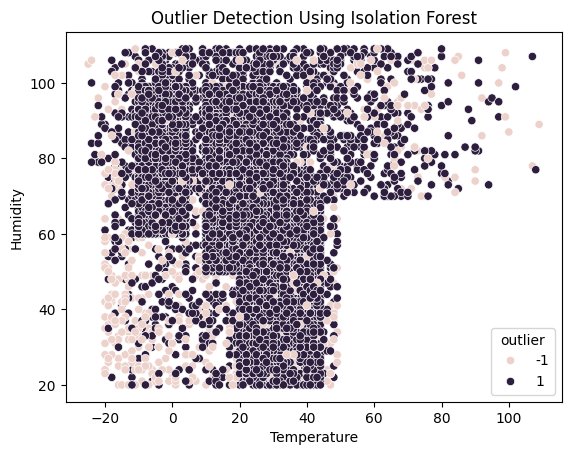

In [7]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05)
df_copy = df.copy()
df_copy['outlier'] = iso.fit_predict(df_copy[num_cols])


sns.scatterplot(x=df_copy['Temperature'], y=df_copy['Humidity'], hue=df_copy['outlier'])
plt.title("Outlier Detection Using Isolation Forest")
plt.show()


**Z-score**

In [8]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df[num_cols]))
df_outliers = df[(z_scores > 3).any(axis=1)]
print("Outlier rows:")
df_outliers.head()


Outlier rows:


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
10,35.0,45,6.0,86.0,partly cloudy,879.88,2,Spring,1.0,mountain,Cloudy
38,-9.0,49,1.5,58.0,partly cloudy,1132.20,8,Spring,16.5,mountain,Snowy
63,3.0,75,46.5,87.0,overcast,996.85,5,Winter,4.5,inland,Snowy
85,32.0,35,2.5,63.0,partly cloudy,1160.48,2,Winter,0.0,coastal,Sunny
93,14.0,44,9.0,11.0,partly cloudy,853.01,14,Winter,3.5,coastal,Rainy


In [9]:
from scipy import stats
import numpy as np
import pandas as pd

numeric_df = df.select_dtypes(include='number')

# Compute z-scores
z = pd.DataFrame(np.abs(stats.zscore(numeric_df)),
                 columns=numeric_df.columns,
                 index=numeric_df.index)

# Masks
outlier_mask = z > 3
normal_mask  = z <= 3

summary = {}

for col in numeric_df.columns:
    # Top 3 outliers
    out_vals = df.loc[outlier_mask[col], col].dropna().head(3).values
    # Top 3 normals
    norm_vals = df.loc[normal_mask[col], col].dropna().head(3).values

    # Convert to series, length may be < 3
    out_series = pd.Series(out_vals)
    norm_series = pd.Series(norm_vals)

    summary[col + "_Outliers"] = out_series
    summary[col + "_Normal"]   = norm_series

# Build table
comparison_table = pd.DataFrame(summary)

# Replace NaN with clean placeholder
comparison_table = comparison_table.fillna("—")

comparison_table


,Temperature_Outliers,Temperature_Normal,Humidity_Outliers,Humidity_Normal,Wind Speed_Outliers,Wind Speed_Normal,Precipitation (%)_Outliers,Precipitation (%)_Normal,Atmospheric Pressure_Outliers,Atmospheric Pressure_Normal,UV Index_Outliers,UV Index_Normal,Visibility (km)_Outliers,Visibility (km)_Normal
0,78.0,14.0,—,73,46.5,9.5,—,82.0,879.88,1010.82,—,2,16.5,3.5
1,73.0,39.0,—,96,34.0,8.5,—,71.0,1132.20,1011.43,—,7,17.5,10.0
2,80.0,30.0,—,64,47.0,7.0,—,16.0,1160.48,1018.72,—,5,17.0,5.5


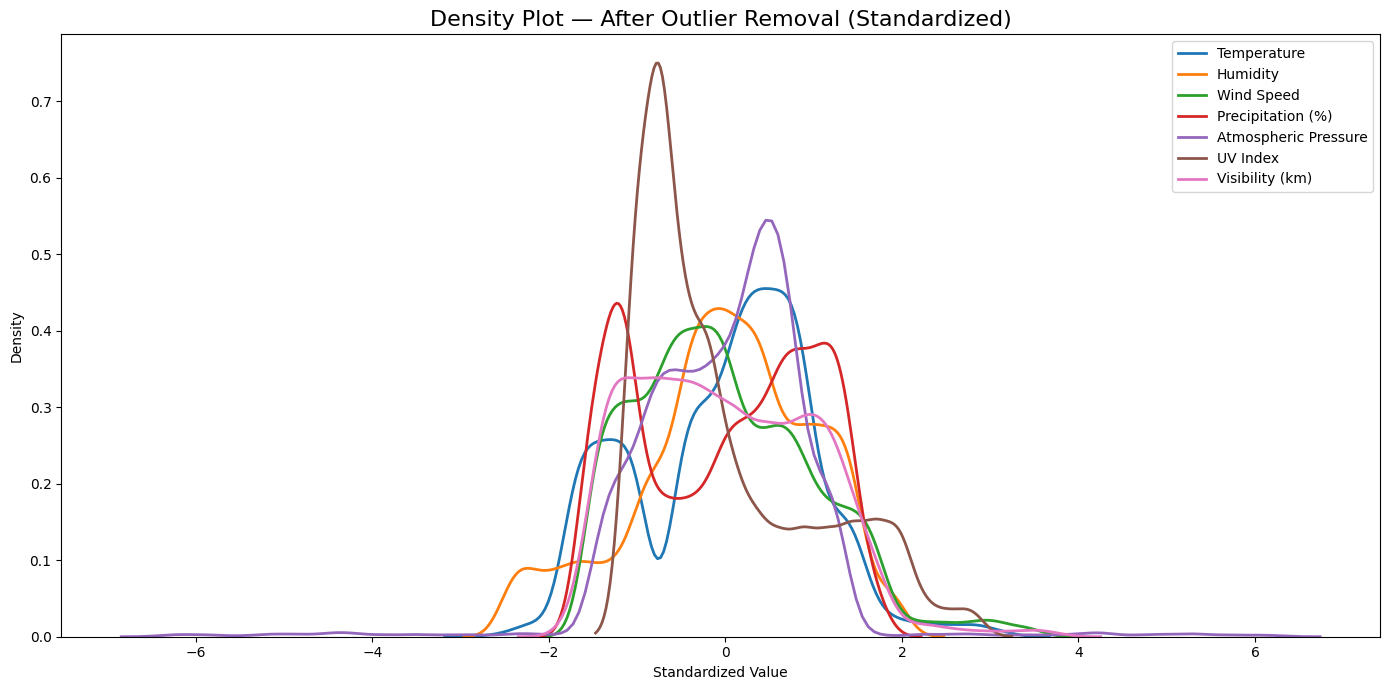

In [10]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import numpy as np


numeric_df = df.select_dtypes(include='number')

z_scores = np.abs(stats.zscore(numeric_df))
df_clean = df[(z_scores < 3).all(axis=1)]


# Select numeric columns from cleaned DataFrame
numeric_clean = df_clean.select_dtypes(include='number')

# Standardize so all columns have mean=0 and std=1
scaled_clean = StandardScaler().fit_transform(numeric_clean)
scaled_clean_df = pd.DataFrame(scaled_clean, columns=numeric_clean.columns)

plt.figure(figsize=(14,7))

# Plot all KDEs after scaling — same style as before
for col in scaled_clean_df.columns:
    sns.kdeplot(scaled_clean_df[col], fill=False, linewidth=2, label=col)

plt.title("Density Plot — After Outlier Removal (Standardized)", fontsize=16)
plt.xlabel("Standardized Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
print(f"Rows Before Cleaning: {len(df)}")
print(f"Rows After Cleaning:  {len(df_clean)}")

Rows Before Cleaning: 13200
Rows After Cleaning:  12151


In [12]:
# Statistics for original data (before cleaning)
stats_before = numeric_df.describe().T
stats_before.rename(columns=lambda c: f"Before_{c}", inplace=True)

# Statistics for cleaned data (after outlier removal)
numeric_clean = df_clean.select_dtypes(include='number')
stats_after = numeric_clean.describe().T
stats_after.rename(columns=lambda c: f"After_{c}", inplace=True)

# Merge both tables
stats_comparison = pd.concat([stats_before, stats_after], axis=1)

stats_comparison


,Before_count,Before_mean,Before_std,Before_min,Before_25%,Before_50%,Before_75%,Before_max,After_count,After_mean,After_std,After_min,After_25%,After_50%,After_75%,After_max
Temperature,13200.0,19.127576,17.386327,-25.00,4.0,21.00,31.0000,109.00,12151.0,19.015966,16.172768,-25.00,4.000,22.00,30.00,71.00
Humidity,13200.0,68.710833,20.194248,20.00,57.0,70.00,84.0000,109.00,12151.0,69.293062,19.683611,20.00,59.000,70.00,84.00,109.00
Wind Speed,13200.0,9.832197,6.908704,0.00,5.0,9.00,13.5000,48.50,12151.0,9.434820,5.984465,0.00,5.000,8.50,13.50,30.50
Precipitation (%),13200.0,53.644394,31.946541,0.00,19.0,58.00,82.0000,109.00,12151.0,52.640935,32.055038,0.00,19.000,57.00,81.00,109.00
Atmospheric Pressure,13200.0,1005.827896,37.199589,800.12,994.8,1007.65,1016.7725,1199.21,12151.0,1006.150373,17.519788,894.24,995.555,1007.78,1016.38,1116.16
UV Index,13200.0,4.005758,3.856600,0.00,1.0,3.00,7.0000,14.00,12151.0,3.737388,3.684748,0.00,1.000,2.00,6.00,14.00
Visibility (km),13200.0,5.462917,3.371499,0.00,3.0,5.00,7.5000,20.00,12151.0,5.152703,2.727016,0.00,3.000,5.00,7.50,15.50


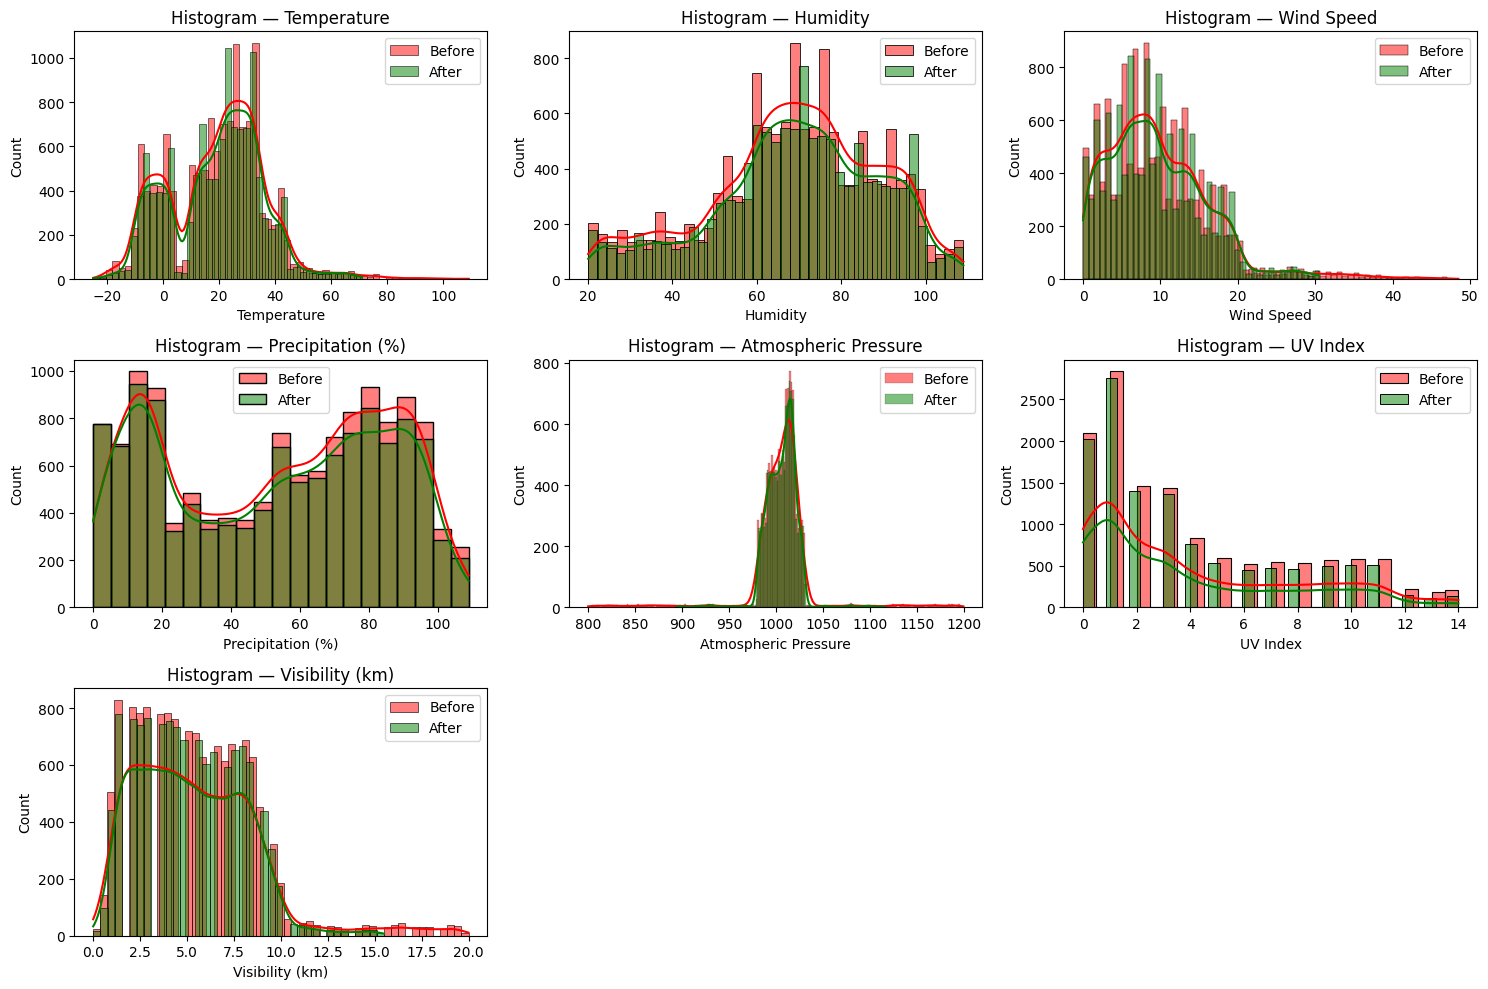

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_df.columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(numeric_df[col], color="red", kde=True, label="Before", alpha=0.5)
    sns.histplot(numeric_clean[col], color="green", kde=True, label="After", alpha=0.5)
    plt.title(f"Histogram — {col}")
    plt.legend()

plt.tight_layout()
plt.show()


# **Identifying Irrelevant Features (Dark Data)**

**Correlation Matrix**

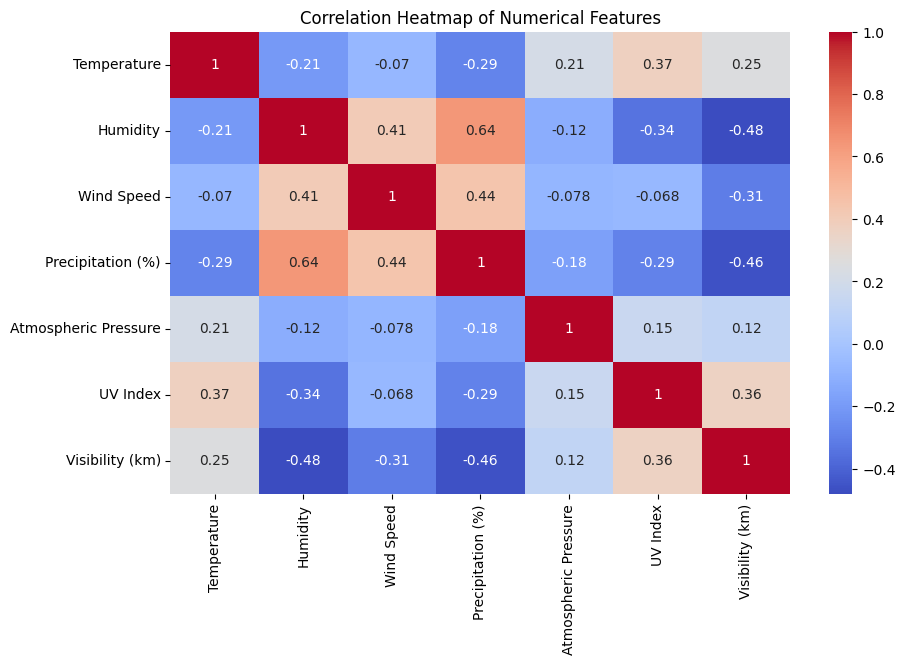

In [14]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


**Feature Importance - Random Forest**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


df_before = df.dropna().copy()
df_after = df_clean.dropna().copy()

def encode(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = LabelEncoder().fit_transform(df[col])
    return df

df_before_enc = encode(df_before)
df_after_enc  = encode(df_after)


X_before = df_before_enc.drop("Weather Type", axis=1)
y_before = df_before_enc["Weather Type"]


model_before = RandomForestClassifier()
model_before.fit(X_before, y_before)


fi_before = pd.Series(model_before.feature_importances_, index=X_before.columns)
fi_sorted = fi_before.sort_values()


plt.figure(figsize=(9,6))


colors = sns.color_palette("viridis", len(fi_sorted))

plt.barh(fi_sorted.index, fi_sorted.values, color=colors)

plt.title("Feature Importance — Before Cleaning", fontsize=15)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

X_after = df_after_enc.drop("Weather Type", axis=1)
y_after = df_after_enc["Weather Type"]

model_after = RandomForestClassifier()
model_after.fit(X_after, y_after)

fi_after = pd.Series(model_after.feature_importances_, index=X_after.columns)
fi_after_sorted = fi_after.sort_values()

plt.figure(figsize=(9,6))

colors = sns.color_palette("viridis", len(fi_after_sorted))

plt.barh(fi_after_sorted.index, fi_after_sorted.values, color=colors)

plt.title("Feature Importance — After Cleaning", fontsize=15)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# **Accuracy Comparison**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay


Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_before, y_before, test_size=0.2, random_state=42)
clf_before = RandomForestClassifier(random_state=42).fit(Xb_train, yb_train)
acc_before = accuracy_score(yb_test, clf_before.predict(Xb_test))

Xa_train, Xa_test, ya_train, ya_test = train_test_split(X_after, y_after, test_size=0.2, random_state=42)
clf_after = RandomForestClassifier(random_state=42).fit(Xa_train, ya_train)
acc_after = accuracy_score(ya_test, clf_after.predict(Xa_test))

plt.figure(figsize=(7,5))
values = [acc_before, acc_after]
bars = plt.bar(["Before Cleaning", "After Cleaning"], values)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f"{val:.3f}", ha='center', va='center', fontsize=13, color='white', fontweight='bold')

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()


plt.figure(figsize=(7,7))
disp_before = ConfusionMatrixDisplay.from_predictions(
    yb_test,
    clf_before.predict(Xb_test),
    cmap="Blues"
)
disp_before.ax_.grid(False)
plt.title("Confusion Matrix — Before Cleaning")
plt.tight_layout()
plt.show()



plt.figure(figsize=(7,7))
disp_after = ConfusionMatrixDisplay.from_predictions(
    ya_test,
    clf_after.predict(Xa_test),
    cmap="Blues"
)
disp_after.ax_.grid(False)
plt.title("Confusion Matrix — After Cleaning")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

df = df.dropna()

y = df["Weather Type"]
X = df.drop("Weather Type", axis=1)

X = X.select_dtypes(include='number')

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf_full = RandomForestClassifier(random_state=42)
clf_full.fit(X_train, y_train)

acc_full = accuracy_score(y_test, clf_full.predict(X_test))

# Feature importance
feat_importance = pd.Series(clf_full.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature importance:\n", feat_importance)

# Select top 3 important features
top3_features = feat_importance.index[:3]
X_top3 = X[top3_features]

X_train_top3, X_test_top3, y_train_top3, y_test_top3 = train_test_split(X_top3, y, test_size=0.2, random_state=42)
clf_top3 = RandomForestClassifier(random_state=42)
clf_top3.fit(X_train_top3, y_train_top3)

acc_top3 = accuracy_score(y_test_top3, clf_top3.predict(X_test_top3))

plt.figure(figsize=(7,5))
values = [acc_full, acc_top3]
bars = plt.bar(["All Features", "Top 3 Features"], values, color=['#1f77b4','#ff7f0e'])

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f"{val:.3f}", ha='center', va='center', fontsize=13, color='white', fontweight='bold')

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(7,7))
ConfusionMatrixDisplay.from_predictions(y_test, clf_full.predict(X_test), cmap="Blues")
plt.title("Confusion Matrix — All Numeric Features")
plt.show()

plt.figure(figsize=(7,7))
ConfusionMatrixDisplay.from_predictions(y_test_top3, clf_top3.predict(X_test_top3), cmap="Blues")
plt.title("Confusion Matrix — Top 3 Features")
plt.show()
